 # Clustering

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [ ]:
data = pd.read_csv("https://raw.githubusercontent.com/ProfAI/machine-learning-fondamenti/refs/heads/main/datasets/mall_customers.csv")
RANDOM_SEED = 2

## Clean the DataSet

In [ ]:
# Clean dataset from useless features
dataSet = data.drop(columns=["CustomerID", "Gender"], axis=1)

# Split the dataset into different sets for comparison
dataSets = list()
dataSet_Age_SS = dataSet[["Age", "Spending Score (1-100)"]].values
dataSet_AI_SS = dataSet[["Annual Income (k$)", "Spending Score (1-100)"]].values
dataSet_all = dataSet.values

dataSets.append(dataSet_Age_SS)
dataSets.append(dataSet_AI_SS)
dataSets.append(dataSet_all)


## Create KMeans Model for Clusterin

In [12]:
def train_x_models(x, dataSet, label=None):
    ssd = {}
    for i in range(1, x):
        model = KMeans(n_clusters=i, init="k-means++", random_state=RANDOM_SEED)
        model.fit(dataSet)
        ssd[i] = model.inertia_
    plt.plot(list(ssd.keys()), list(ssd.values()), marker='o', label=label)
    plt.ylabel("Number of Clusters", fontsize=16)
    plt.xlabel("Distance Sum Squared", fontsize=16)
    plt.grid(True)


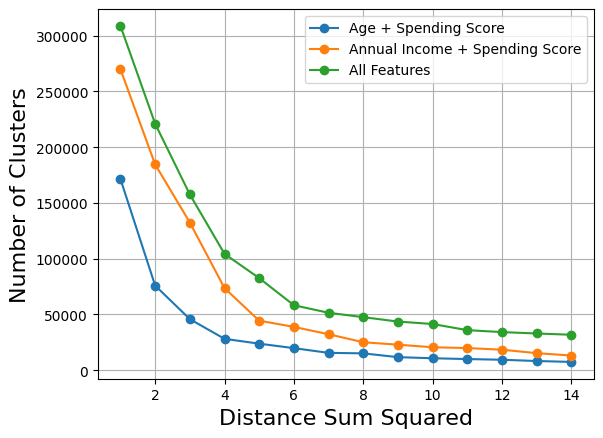

In [13]:
labels = ["Age + Spending Score", "Annual Income + Spending Score", "All Features"]
for X, label in zip(dataSets, labels):
    train_x_models(15, X, label=label)

plt.legend()
plt.show()


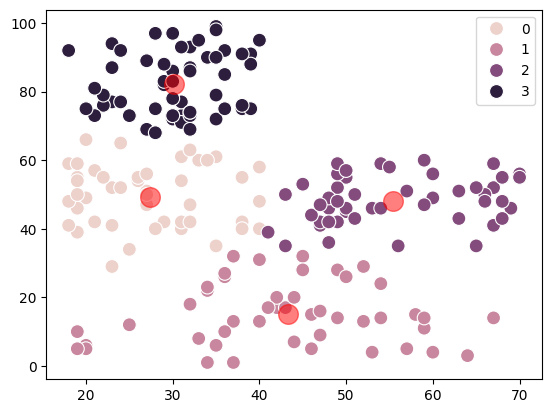

In [18]:
best_model = KMeans(n_clusters=4, init="k-means++", random_state=RANDOM_SEED)
best_model.fit(dataSet_Age_SS)
y_pred = best_model.predict(dataSet_Age_SS)
centers = best_model.cluster_centers_

sns.scatterplot(x=dataSet_Age_SS[:,0], y=dataSet_Age_SS[:,1], hue=y_pred, s=100) 
plt.scatter(centers[:,0], centers[:, 1], color='red', s=200, alpha=.5)
plt.show()
